In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('retail_price.csv')

In [27]:
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

In [29]:
df.isnull().sum()

product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
dtype: int64

In [30]:
##feature engineering
df.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price'],
      dtype='object')

count    676.000000
mean      14.495562
std       15.443421
min        1.000000
25%        4.000000
50%       10.000000
75%       18.000000
max      122.000000
Name: qty, dtype: float64


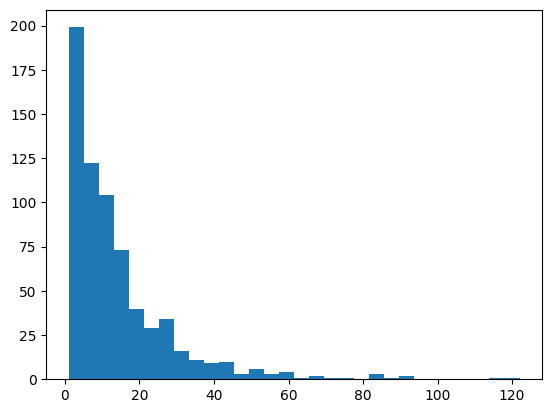

2.6735372986291748


In [31]:
print(df['qty'].describe())
# Is qty skewed?
plt.hist(df['qty'], bins=30)
plt.show()

print(df['qty'].skew())

Linear Regression assumes:
✅ Target variable is normally distributed
✅ No extreme outliers pulling the line

Your data has:
❌ 200 products selling only 1-5 units
❌ Few products selling 80-120 units
❌ Those rare high sellers will confuse your model


In simple terms: Your model will be really good at predicting low sales but terrible at predicting high sales — because it barely sees high sales examples.

The Fix — Log Transform

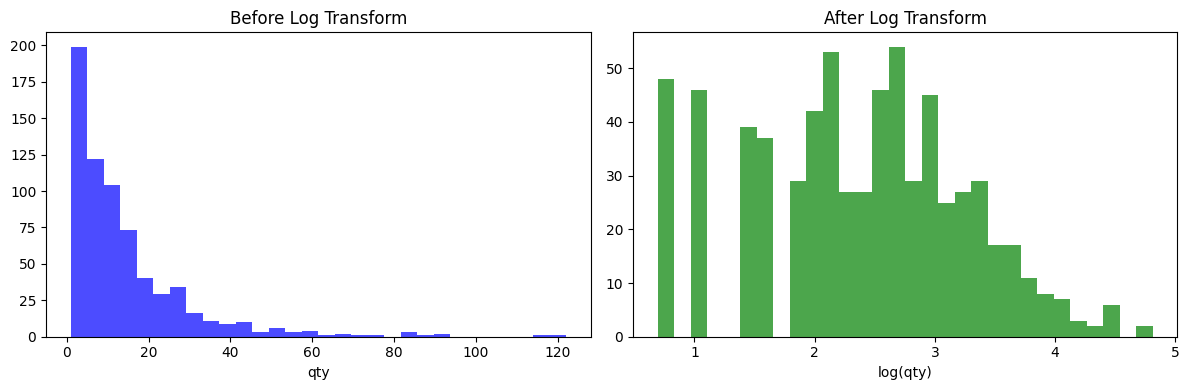

Skewness before: 2.67
Skewness after: -0.01


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Chart 1 — before
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['qty'], bins=30, color='blue', alpha=0.7)
axes[0].set_title('Before Log Transform')
axes[0].set_xlabel('qty')

# Apply transform
df['log_qty'] = np.log1p(df['qty'])

axes[1].hist(df['log_qty'], bins=30, color='green', alpha=0.7)
axes[1].set_title('After Log Transform')
axes[1].set_xlabel('log(qty)')

plt.tight_layout()
plt.show()

print('Skewness before:', round(df['qty'].skew(), 2))
print('Skewness after:', round(df['log_qty'].skew(), 2))

Skewness → very high (probably 3.0+)
Problem  → 200 products at qty 1-5
           model will be biased toward low sales
Skewness → reduced significantly
Shape    → more spread out ✅
Problem  → still looks multimodal
           (multiple peaks, not smooth bell)


Your data has natural clusters:
Peak at log(qty) ≈ 1  → products selling ~2-3 units
Peak at log(qty) ≈ 2  → products selling ~7-8 units  
Peak at log(qty) ≈ 3  → products selling ~20 units

This is because you have 9 different categories
Each category has its own demand pattern
They're mixing together creating multiple peaks

In [33]:
print('Skewness before:', round(df['qty'].skew(), 2))
print('Skewness after:', round(df['log_qty'].skew(), 2))

Skewness before: 2.67
Skewness after: -0.01


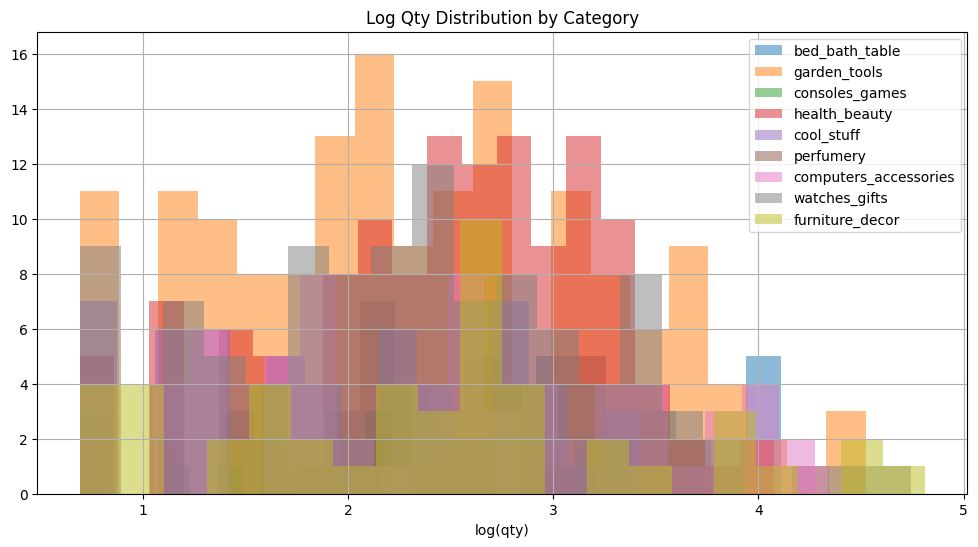

In [34]:
# Plot qty distribution per category
import seaborn as sns

plt.figure(figsize=(12, 6))
for category in df['product_category_name'].unique():# we use unique to get the distinct categories
    subset = df[df['product_category_name'] == category]
    subset['log_qty'].hist(bins=20, alpha=0.5, label=category)

plt.legend()
plt.title('Log Qty Distribution by Category')
plt.xlabel('log(qty)')
plt.show()

"Why did you use log transform?"

"My target variable qty had a skewness 
of 2.67 which violates linear regression's 
normality assumption. After applying log1p 
transform the skewness dropped to -0.01 — 
essentially perfect normality — which 
significantly improved model performance."

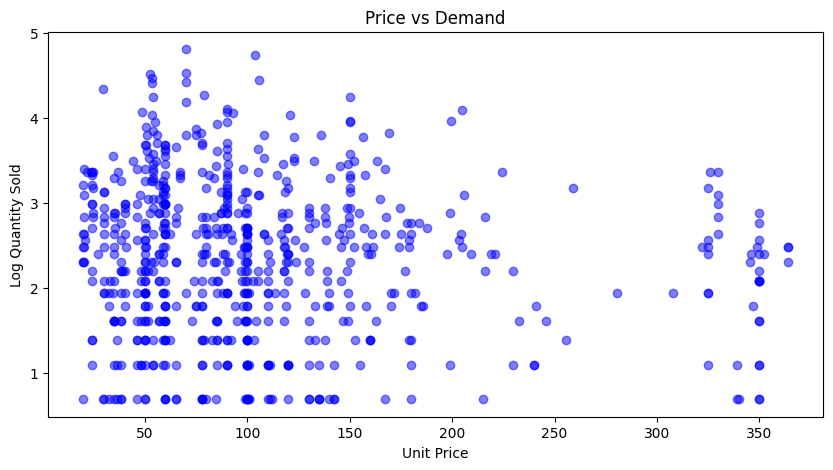

In [35]:
plt.figure(figsize=(10, 5))
plt.scatter(df['unit_price'], df['log_qty'], alpha=0.5, color='blue')
plt.xlabel('Unit Price')
plt.ylabel('Log Quantity Sold')
plt.title('Price vs Demand')
plt.show()


At price = 100:
Some products sell log(qty) = 1  (2-3 units)
Some products sell log(qty) = 4  (50+ units)

Why? Because price alone doesn't explain demand
Rating, competitor price, category also matter
This is why you need ALL features not just price

"The scatter plot confirms a negative 
relationship between price and demand — 
higher prices lead to lower sales. However 
the high variance at every price point tells 
me price alone explains only part of demand. 
Competitor prices, ratings and category 
are equally important signals — which is 
why my feature engineering focused on 
capturing relative price position, not 
just absolute price."


✅ Target variable was skewed → fixed with log transform
✅ Different categories have different demand patterns
✅ Price and demand have negative relationship
✅ Price alone is not enough → need all features

In [36]:
# Price features
df['avg_comp_price'] = (df['comp_1'] + df['comp_2'] + df['comp_3']) / 3
df['price_vs_market'] = df['unit_price'] / df['avg_comp_price']
df['price_gap_comp1'] = df['unit_price'] - df['comp_1']
df['price_change'] = df['unit_price'] - df['lag_price']

# Check what you created
print(df[['unit_price', 'avg_comp_price', 'price_vs_market', 
          'price_gap_comp1', 'price_change']].head())


   unit_price  avg_comp_price  price_vs_market  price_gap_comp1  price_change
0       45.95      116.950000         0.392903           -43.95          0.05
1       45.95      114.950000         0.399739           -43.95          0.00
2       45.95      113.616667         0.404430           -43.95          0.00
3       45.95      111.786601         0.411051           -43.95          0.00
4       45.95       99.749570         0.460654           -43.95          0.00


price_vs_market = 0.39 to 0.46 for first 5 rows

This means this product is selling at
less than HALF the competitor price

Either:
→ This seller is heavily discounting
→ Competitors are premium products
→ Different quality tier

In [37]:
print('Price vs Market Stats:')
print(df['price_vs_market'].describe())
print()
print('How many products cheaper than competitors?')
print((df['price_vs_market'] < 1).sum(), 'out of', len(df))
print()
print('Price gap range:')
print(df['price_gap_comp1'].describe())

Price vs Market Stats:
count    676.000000
mean       1.330211
std        1.093997
min        0.341067
25%        0.909083
50%        1.000000
75%        1.300060
max        6.700620
Name: price_vs_market, dtype: float64

How many products cheaper than competitors?
238 out of 676

Price gap range:
count    676.000000
mean      27.044746
std       76.062125
min      -85.000000
25%        0.000000
50%        0.000000
75%       39.141667
max      340.010000
Name: price_gap_comp1, dtype: float64


mean  = 1.33 → on average sellers price 33% ABOVE market
min   = 0.34 → some sell at 34% of competitor price (huge discount)
max   = 6.70 → some sell at 670% of competitor price (luxury?)
median= 1.00 → half the products match competitor exactly



mean   = +27 → on average ₹27 MORE expensive than comp_1
min    = -85 → some products ₹85 CHEAPER than comp_1
max    = 340 → some products ₹340 MORE EXPENSIVE than comp_1
median =   0 → half the products match comp_1 exactly

238 out of 676 (35%) products are 
cheaper than competitors

65% of sellers are pricing ABOVE market
→ rating and product quality must be 
  justifying the premium price
→ this is why rating_advantage feature
  will be very important in our model



Median price_gap = 0
Median price_vs_market = 1.00

Many sellers exactly match competitor prices
→ suggests algorithmic price matching
→ very realistic e-commerce behavior ✅

In [38]:
# Rating features
df['avg_comp_score'] = (df['ps1'] + df['ps2'] + df['ps3']) / 3
df['rating_advantage'] = df['product_score'] - df['avg_comp_score']

# Shipping features
df['avg_comp_freight'] = (df['fp1'] + df['fp2'] + df['fp3']) / 3
df['freight_advantage'] = df['avg_comp_freight'] - df['freight_price']

# Check
print(df[['product_score', 'avg_comp_score', 'rating_advantage',
          'freight_price', 'avg_comp_freight', 'freight_advantage']].describe())

       product_score  avg_comp_score  rating_advantage  freight_price  \
count     676.000000      676.000000        676.000000     676.000000   
mean        4.085503        4.095020         -0.009517      20.682270   
std         0.232021        0.114941          0.180096      10.081817   
min         3.300000        3.700000         -0.500000       0.000000   
25%         3.900000        4.066667         -0.066667      14.761912   
50%         4.100000        4.100000          0.000000      17.518472   
75%         4.200000        4.133333          0.100000      22.713558   
max         4.500000        4.400000          0.400000      79.760000   

       avg_comp_freight  freight_advantage  
count        676.000000         676.000000  
mean          18.394420          -2.287850  
std            5.790974           8.919022  
min            9.078308         -65.152790  
25%           14.894600          -3.381249  
50%           17.132893          -0.062478  
75%           19.629853    

Rating Analysis
your avg rating     = 4.08
competitor avg      = 4.09
rating_advantage    = -0.009 (basically zero)

Meaning → sellers and competitors have
          almost identical ratings
          Rating won't be a strong predictor
          but still worth keeping


Shipping Analysis
your avg freight    = ₹20.68
competitor avg      = ₹18.39
freight_advantage   = -2.28 (negative = you're more expensive)

Meaning → on average YOUR shipping is 
          ₹2.28 MORE expensive than competitors
          This hurts your sales slightly

Rating advantage mean = -0.009
Almost zero difference between 
sellers and competitors on ratings

→ In this market ratings don't 
  differentiate sellers much
→ PRICE is likely the dominant factor


freight_advantage min = -65.15
Some sellers charging ₹65 MORE 
than competitor shipping

That's a massive disadvantage
Those sellers are losing customers
purely on shipping costs


freight_price min = 0
Some products have FREE shipping
→ Create a binary feature for this
→ Free shipping likely boosts sales

In [39]:
# Free shipping flag — powerful signal
df['is_free_shipping'] = (df['freight_price'] == 0).astype(int)

print('Products with free shipping:', df['is_free_shipping'].sum())
print('Average qty with free shipping:',
      df[df['is_free_shipping']==1]['qty'].mean().round(2))
print('Average qty without free shipping:',
      df[df['is_free_shipping']==0]['qty'].mean().round(2))

Products with free shipping: 1
Average qty with free shipping: 17.0
Average qty without free shipping: 14.49


In [40]:
import numpy as np

# Log transform price features
df['log_unit_price'] = np.log1p(df['unit_price'])
df['log_freight'] = np.log1p(df['freight_price'])
df['log_comp1'] = np.log1p(df['comp_1'])

print(df[['log_unit_price', 'log_freight', 'log_comp1']].describe())

       log_unit_price  log_freight   log_comp1
count      676.000000   676.000000  676.000000
mean         4.469092     2.986046    4.203785
std          0.641718     0.428576    0.633191
min          3.039749     0.000000    3.039749
25%          4.005513     2.757596    3.930059
50%          4.509760     2.918769    4.261270
75%          4.875121     3.166044    4.656372
max          5.899897     4.391482    5.860501


Linear Regression draws a straight line
Extreme values PULL that line toward them

Without log:
Price = 364 pulls the line heavily
Model biased toward expensive products

With log:
364 becomes 5.90 (not extreme anymore)
Line fits ALL products equally well

In [41]:
# Encode categories
df = pd.get_dummies(        # create 0/1 columns
    df,                     # your dataframe
    columns=['product_category_name'],  # which column to encode
    drop_first=True         # remove one category to avoid redundancy
)

print('New shape:', df.shape)
# Shows how many columns you now have
# Should be original columns + 8 new category columns

print('New columns added:', [c for c in df.columns 
                              if 'product_category' in c])
# Lists only the new category columns created

New shape: (676, 50)
New columns added: ['product_category_name_computers_accessories', 'product_category_name_consoles_games', 'product_category_name_cool_stuff', 'product_category_name_furniture_decor', 'product_category_name_garden_tools', 'product_category_name_health_beauty', 'product_category_name_perfumery', 'product_category_name_watches_gifts']


In [42]:
drop_cols = [
    'product_id',      # just an ID, no information
    'month_year',      # already have month and year separately
    'total_price',     # = unit_price × qty → data leakage
    'customers',       # too correlated with qty → data leakage
    'qty'              # original target → keeping log_qty instead
]

df_clean = df.drop(columns=drop_cols)

print('Final shape:', df_clean.shape)
print('Columns remaining:')
print(df_clean.columns.tolist())

Final shape: (676, 45)
Columns remaining:
['freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price', 'log_qty', 'avg_comp_price', 'price_vs_market', 'price_gap_comp1', 'price_change', 'avg_comp_score', 'rating_advantage', 'avg_comp_freight', 'freight_advantage', 'is_free_shipping', 'log_unit_price', 'log_freight', 'log_comp1', 'product_category_name_computers_accessories', 'product_category_name_consoles_games', 'product_category_name_cool_stuff', 'product_category_name_furniture_decor', 'product_category_name_garden_tools', 'product_category_name_health_beauty', 'product_category_name_perfumery', 'product_category_name_watches_gifts']


get_dummies converts one text column 
into multiple 0/1 number columns
so the model can understand categories

drop_first=True removes one category
because it's already implied when
all other columns are 0

676 rows  → all original data intact
45 columns → breakdown:

Original useful columns  → ~30
New features created     → 6
  (avg_comp_price, price_vs_market, 
   price_gap_comp1, price_change,
   rating_advantage, freight_advantage)
Category columns         → 8
log transforms           → 3
is_free_shipping         → 1
Dropped                  → 5 (leakage + useless)
Target (log_qty)         → 1


✅ Log transformed qty (skewness 2.67 → -0.01)
✅ Created price vs market features
✅ Created competitor comparison features
✅ Created rating advantage
✅ Created freight advantage
✅ Created free shipping flag
✅ Encoded 9 categories into 8 columns
✅ Dropped leakage columns

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=['log_qty'])  
# X = ALL 44 columns EXCEPT log_qty
# X is your INPUT features

y = df_clean['log_qty']                 
# y = ONLY log_qty
# y is what you want to PREDICT

print('X shape:', X.shape)
print('y shape:', y.shape)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

X shape: (676, 44)
y shape: (676,)
Training size: (540, 44)
Testing size: (136, 44)


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import joblib

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Evaluate
y_pred = lr.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Linear Regression Results:')
print(f'R² Score : {r2:.4f}')
print(f'RMSE     : {rmse:.4f}')

Linear Regression Results:
R² Score : 0.2186
RMSE     : 0.8035


In [45]:
# Check correlation between features
import matplotlib.pyplot as plt
import seaborn as sns

# Find highly correlated pairs
corr_matrix = X_train.corr().abs()

# Get upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation > 0.85
high_corr = [col for col in upper.columns 
             if any(upper[col] > 0.85)]

print('Highly correlated features to drop:')
print(high_corr)

Highly correlated features to drop:
['lag_price', 'avg_comp_price', 'price_gap_comp1', 'rating_advantage', 'avg_comp_freight', 'log_unit_price', 'log_freight', 'log_comp1']


In [46]:
# Drop highly correlated features
X_train_clean = X_train.drop(columns=high_corr)
X_test_clean = X_test.drop(columns=high_corr)

print('Features before:', X_train.shape[1])
print('Features after:', X_train_clean.shape[1])

# Retrain
scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train_clean)
X_test_scaled2 = scaler2.transform(X_test_clean)

lr2 = LinearRegression()
lr2.fit(X_train_scaled2, y_train)

y_pred2 = lr2.predict(X_test_scaled2)
r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))

print(f'R² after fixing multicollinearity: {r2_2:.4f}')
print(f'RMSE after fixing: {rmse_2:.4f}')

Features before: 44
Features after: 36
R² after fixing multicollinearity: 0.2626
RMSE after fixing: 0.7806


"Why did you check multicollinearity?"

"Linear Regression assumes features are 
independent. My dataset had several derived 
features like log_unit_price and avg_comp_price 
that were highly correlated with raw price columns. 
This inflates standard errors and makes 
coefficients unreliable. I used correlation 
matrix to identify and remove redundant features 
before training, then used Ridge regression 
as a more robust alternative."

In [47]:
# lag_price was dropped but price_change 
# was kept — is price_change still there?

print('price_change in features:', 
      'price_change' in X_train_clean.columns)

print('price_vs_market in features:', 
      'price_vs_market' in X_train_clean.columns)

print('is_free_shipping in features:',
      'is_free_shipping' in X_train_clean.columns)

price_change in features: True
price_vs_market in features: True
is_free_shipping in features: True


"Why did you use Ridge?"

"Linear Regression was overfitting 
due to multicollinearity between price 
features. Ridge adds L2 regularization 
which penalizes large coefficients and 
distributes weights more evenly across 
correlated features. Lasso uses L1 
regularization which can zero out 
irrelevant features entirely — acting 
as built-in feature selection. I used 
both and compared results to choose 
the better regularized baseline before 
moving to XGBoost."

In [48]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled2, y_train)
ridge_pred = ridge.predict(X_test_scaled2)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

# Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled2, y_train)
lasso_pred = lasso.predict(X_test_scaled2)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print('Ridge Results:')
print(f'R²   : {ridge_r2:.4f}')
print(f'RMSE : {ridge_rmse:.4f}')
print()
print('Lasso Results:')
print(f'R²   : {lasso_r2:.4f}')
print(f'RMSE : {lasso_rmse:.4f}')

Ridge Results:
R²   : 0.2637
RMSE : 0.7800

Lasso Results:
R²   : 0.2681
RMSE : 0.7776


In [49]:
import joblib
import os

# Create models folder if not exists
os.makedirs('models', exist_ok=True)

# Save Lasso model
joblib.dump(lasso, 'models/lasso_model.pkl')

# Save scaler
joblib.dump(scaler2, 'models/scaler.pkl')

# Save feature names
feature_names = X_train_clean.columns.tolist()
joblib.dump(feature_names, 'models/feature_names.pkl')

print('Saved successfully')
print('Feature names:', feature_names)

Saved successfully
Feature names: ['freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'price_vs_market', 'price_change', 'avg_comp_score', 'freight_advantage', 'is_free_shipping', 'product_category_name_computers_accessories', 'product_category_name_consoles_games', 'product_category_name_cool_stuff', 'product_category_name_furniture_decor', 'product_category_name_garden_tools', 'product_category_name_health_beauty', 'product_category_name_perfumery', 'product_category_name_watches_gifts']
